# Thesis: restore the original seven-emotion comparisons

This notebook adds **anger, disgust, fear, joy, neutral, sadness and surprise** alongside the corrected VAD analysis. It keeps the **same 4,256 participants, 6,345,978 eligible tweets, 47,204 participant-song records and saved participant folds**.

**What stays the same as the original thesis:** the seven-category vocabulary and the category-versus-VAD comparison. The original table is included for reference.

**What necessarily changes:** the original `j-hartmann/emotion-english-distilroberta-base` checkpoint requires text. The public timeline release contains MiniLM embeddings, so that checkpoint cannot be applied directly. This notebook trains an independently evaluated **seven-category logistic classifier on GoEmotions**, using the published Ekman mapping and the same MiniLM encoder as the VAD model. It is an adaptation, not a reproduction of the original checkpoint. The full GoEmotions dataset has 27 emotions plus neutral; the original seven-class model was trained on several datasets, including GoEmotions.


## 1. Install packages


In [1]:
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'sentence-transformers>=5,<7', 'scikit-learn>=1.5,<2',
    'statsmodels>=0.14,<1', 'pandas>=2.2,<4', 'scipy>=1.11,<2',
    'matplotlib>=3.8,<4', 'tqdm', 'requests'
])


0

## 2. Connect Drive and choose paths
`EXISTING_TWEET_FOLDER` is optional. Point it to a folder containing the five released `.npy` files to avoid downloading them. The input ZIP goes in `MyDrive` by default. Results and checkpoints are saved under `Thesis_GoEmotions_Comparison`.

Leave the scientific settings fixed for the primary run. The bootstrap intervals condition on saved model predictions; they do not include complete model retraining uncertainty.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

INPUT_ZIP = Path('/content/drive/MyDrive/GoEmotions-Colab-inputs.zip')
PROJECT = Path('/content/drive/MyDrive/Thesis_GoEmotions_Comparison')
EXISTING_TWEET_FOLDER = Path('/content/drive/MyDrive/Thesis docs')
ALLOW_TWEET_DOWNLOAD = True
DELETE_LOCAL_TWEET_FILES_AFTER_SCORING = True
INCLUDE_RANDOM_FOREST = True
BOOTSTRAPS = 2000
ENCODING_BATCH_SIZE = 128
TWEET_BATCH_SIZE = 50000

SEED = 42
LABELS = ['anger','disgust','fear','joy','neutral','sadness','surprise']
ENCODER_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
ENCODER_REVISION = '1110a243fdf4706b3f48f1d95db1a4f5529b4d41'
GO_REVISION = '7951440944924ac61b6e2f9a2a3c715834005c40'
CODE_VERSION = 'seven-category-colab-v1'

INPUT = Path('/content/thesis_comparison_inputs/comparison_inputs')
CACHE = PROJECT/'cache'
RESULTS = PROJECT/'results'
LOCAL_TWEETS = Path('/content/thesis_tweet_embeddings')

for p in [PROJECT, CACHE, RESULTS, RESULTS/'model', RESULTS/'analysis', RESULTS/'figures', LOCAL_TWEETS]:
    p.mkdir(parents=True, exist_ok=True)

if not INPUT_ZIP.is_file():
    raise FileNotFoundError(f'Upload GoEmotions-Colab-inputs.zip to Drive or edit INPUT_ZIP. Current path: {INPUT_ZIP}')

print('Results will be saved to:', RESULTS)


Mounted at /content/drive
Results will be saved to: /content/drive/MyDrive/Thesis_GoEmotions_Comparison/results


## 3. Load and verify the existing analysis inputs
The ZIP includes a manifest. Every file is verified before use. The stored tweet row mask already excludes marked diagnosis posts and retweets; the original global embedding order is retained. The full timeline CSV is not needed again.


In [ ]:
import gc, hashlib, importlib.metadata, json, platform, shutil, time, warnings, zipfile
import numpy as np
import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt
from scipy.special import softmax
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score, balanced_accuracy_score, cohen_kappa_score, roc_auc_score
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm
from IPython.display import display, Markdown

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda:f.read(8*1024*1024), b''): h.update(block)
    return h.hexdigest()

def write_json(path, content):
    path=Path(path); part=path.with_name(path.name+'.partial')
    part.write_text(json.dumps(content, indent=2))
    part.replace(path)

def save_npz(path, **arrays):
    path=Path(path); part=path.with_name(path.name+'.partial')
    with part.open('wb') as f: np.savez_compressed(f, **arrays)
    part.replace(path)

INPUT.parent.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(INPUT_ZIP) as z:
    for item in z.infolist():
        dest=(INPUT.parent/item.filename).resolve()
        if not dest.is_relative_to(INPUT.parent.resolve()):
            raise ValueError('Unsafe archive member: '+item.filename)
    z.extractall(INPUT.parent)

input_manifest=json.loads((INPUT/'INPUT_MANIFEST.json').read_text())

for name, item in tqdm(input_manifest['files'].items(), desc='Verifying input files'):
    path=INPUT/name
    assert path.stat().st_size == item['bytes'] and sha256(path) == item['sha256'], name

primary=pd.read_csv(INPUT/'analysis/participant_features_primary.csv',dtype={'participant_id':str})
fold_assignments=pd.read_csv(INPUT/'analysis/fold_assignments.csv',dtype={'participant_id':str})
assert primary.participant_id.tolist() == fold_assignments.participant_id.tolist()
assert primary.disorder.tolist() == fold_assignments.disorder.tolist()
assert len(primary)==4256 and primary.disorder.value_counts().to_dict()=={'control':3502,'depression':754}
assert int(primary.tweet_count.sum())==6345978 and int(primary.song_count.sum())==47204

print('Verified:',len(primary),'participants; VAD values and original folds loaded.')
display(pd.read_csv(INPUT/'model/test_metrics.csv'))


Verifying input files:   0%|          | 0/21 [00:00<?, ?it/s]

Verified: 4256 participants; VAD values and original folds loaded.


,model,dimension,test_n,mae,rmse,r2,pearson_r,spearman_rho
0,ridge,V,1000,0.205116,0.271367,0.381916,0.620098,0.606204
1,ridge,A,1000,0.175353,0.222648,0.179636,0.435012,0.346843
2,ridge,D,1000,0.146956,0.196663,0.125324,0.354699,0.318427
3,training_mean,V,1000,0.245469,0.345174,-0.000020,NaN,NaN
4,training_mean,A,1000,0.190267,0.245973,-0.001256,NaN,NaN
5,training_mean,D,1000,0.156353,0.210290,-0.000087,NaN,NaN


## 4. Download official GoEmotions and map its labels
The Git revision is fixed. The repository mapping combines the 27 emotion labels into six broad categories; neutral remains separate. Multiple fine labels mapping to one broad category count once.

A comment with two distinct mapped categories contributes half of its target weight to each. This preserves all comments while training seven competing scores; it does not assert that people express only one emotion.


In [ ]:
GO_DATA=CACHE/'goemotions';GO_DATA.mkdir(exist_ok=True)
source_files={}

for name in ['train.tsv','dev.tsv','test.tsv','emotions.txt','ekman_mapping.json']:
    path=GO_DATA/name
    url=f'https://raw.githubusercontent.com/google-research/google-research/{GO_REVISION}/goemotions/data/{name}'
    if not path.exists():
        response=requests.get(url,timeout=90);response.raise_for_status()
        path.write_bytes(response.content)
    source_files[name]={'url':url,'sha256':sha256(path),'bytes':path.stat().st_size}

write_json(RESULTS/'model/goemotions_source_manifest.json',{'revision':GO_REVISION,'files':source_files})
fine_labels=(GO_DATA/'emotions.txt').read_text().splitlines()
coarse_mapping=json.loads((GO_DATA/'ekman_mapping.json').read_text())
coarse_mapping['neutral']=['neutral']
fine_to_coarse={fine:LABELS.index(coarse) for coarse, values in coarse_mapping.items() for fine in values}
assert len(fine_labels)==28 and set(fine_labels)==set(fine_to_coarse)

parts=[]

for split,n in [('train',43410),('dev',5426),('test',5427)]:
    part=pd.read_csv(GO_DATA/f'{split}.tsv',sep='\t',names=['text','labels','id'],dtype=str,keep_default_na=False)
    assert len(part)==n and part.text.str.strip().ne('').all()
    part['split']=split;parts.append(part)

go=pd.concat(parts,ignore_index=True)
assert not go.id.duplicated().any(), 'Comment IDs overlap across partitions'

Y=np.zeros((len(go),7),dtype=np.float64)

for i, labels in enumerate(go.labels):
    assigned=sorted({fine_to_coarse[fine_labels[int(label)]] for label in labels.split(',')})
    Y[i,assigned]=1/len(assigned)

gold=Y>0
train_mask=go.split.eq('train').to_numpy()
dev_mask=go.split.eq('dev').to_numpy()
test_mask=go.split.eq('test').to_numpy()

source_config={'code_version':CODE_VERSION,'encoder':ENCODER_NAME,'revision':ENCODER_REVISION,'max_seq_length':256,'GoEmotions_files':source_files,
               'categories':LABELS,'mapping':coarse_mapping,'C_candidates':[0.1,1.0,10.0], 'encoding_packages':{p:importlib.metadata.version(p)
                 for p in ['sentence-transformers','transformers','torch']}}

source_key=hashlib.sha256(json.dumps(source_config,sort_keys=True).encode()).hexdigest()

display(pd.DataFrame({'category':LABELS,'train_positive':gold[train_mask].sum(axis=0),
                      'dev_positive':gold[dev_mask].sum(axis=0),'test_positive':gold[test_mask].sum(axis=0)}))

print('Comments with multiple broad labels:',int((gold.sum(axis=1)>1).sum()))


,category,train_positive,dev_positive,test_positive
0,anger,5579,717,726
1,disgust,793,97,123
2,fear,726,105,98
3,joy,17410,2219,2104
4,neutral,14219,1766,1787
5,sadness,3263,390,379
6,surprise,5367,624,677


Comments with multiple broad labels: 4794


## 5. Encode GoEmotions with frozen MiniLM
The GPU is used when available. The embedding checkpoint is saved every block, so this cell can resume. The encoder is not fine-tuned and never sees depression/control labels.


In [ ]:
from sentence_transformers import SentenceTransformer

DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(min(4, __import__('os').cpu_count() or 1))
print('Encoding device:',DEVICE)

encoder=SentenceTransformer(ENCODER_NAME,revision=ENCODER_REVISION,device=DEVICE)
encoder.max_seq_length=256
embed_path=CACHE/'goemotions_minilm.npy';state_path=CACHE/'goemotions_encoding.json'

if embed_path.exists():
    if not state_path.exists(): raise ValueError('Embedding cache has no manifest; move it aside before retrying.')
    state=json.loads(state_path.read_text())
    assert state['source_key']==source_key, 'Source/encoder changed; use a new PROJECT folder.'
    X_go=np.lib.format.open_memmap(embed_path,mode='r+')
    assert X_go.shape==(len(go),384)
    completed=int(state['completed'])
else:
    X_go=np.lib.format.open_memmap(embed_path,mode='w+',dtype=np.float32,shape=(len(go),384))
    completed=0
    write_json(state_path,{'source_key':source_key,'completed':0,'total':len(go)})

for start in tqdm(range(completed,len(go),2048),desc='Encoding source comments'):
    end=min(start+2048,len(go))
    values=encoder.encode(go.text.iloc[start:end].tolist(),batch_size=ENCODING_BATCH_SIZE,
                          normalize_embeddings=True,convert_to_numpy=True,show_progress_bar=False)
    assert values.shape==(end-start,384) and np.isfinite(values).all()
    X_go[start:end]=values;X_go.flush()
    write_json(state_path,{'source_key':source_key,'completed':end,'total':len(go)})

assert np.isfinite(X_go).all() and np.allclose(np.linalg.norm(X_go,axis=1),1,atol=1e-5)
del encoder
gc.collect()

if DEVICE=='cuda':torch.cuda.empty_cache()
print('All',len(go),'source comments encoded.')


Encoding device: cuda


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding source comments:   0%|          | 0/27 [00:00<?, ?it/s]

All 54263 source comments encoded.


## 6. Select regularisation on development data, then refit
This is multinomial logistic regression for **emotion**, separate from the later logistic regression for depression/control labels. Each source comment has one total unit of fitting weight. No class balancing or feature standardisation is applied to this source model.

The test split is not used to select `C`. Do not change the model after looking at its test results.


In [ ]:
def fit_emotion_model(mask,C):
    rows, classes=np.nonzero(Y[mask])
    embeddings=np.asarray(X_go[mask])[rows]
    weights=Y[mask][rows,classes]
    with warnings.catch_warnings():
        warnings.simplefilter('error',ConvergenceWarning)
        fitted=LogisticRegression(C=C,solver='lbfgs',max_iter=3000,tol=1e-7,random_state=SEED).fit(embeddings,classes,sample_weight=weights)
    assert fitted.classes_.tolist()==list(range(7))
    return fitted

def soft_target_cross_entropy(target,probability):
    return float(-np.mean(np.sum(target*np.log(np.clip(probability,1e-15,1)),axis=1)))

dev_rows=[]

for C in source_config['C_candidates']:
    candidate=fit_emotion_model(train_mask,C)
    loss=soft_target_cross_entropy(Y[dev_mask],candidate.predict_proba(X_go[dev_mask]))
    dev_rows.append({'C':C,'development_cross_entropy':loss})
    print('C =',C,'development cross-entropy =',round(loss,4))

development=pd.DataFrame(dev_rows)
development.to_csv(RESULTS/'model/development_selection.csv',index=False)
selected_C=float(development.sort_values('development_cross_entropy').iloc[0].C)
emotion_model=fit_emotion_model(train_mask|dev_mask,selected_C)

COEF=emotion_model.coef_.copy();INTERCEPT=emotion_model.intercept_.copy()

save_npz(RESULTS/'model/emotion_logistic.npz',coef=COEF,intercept=INTERCEPT,labels=np.array(LABELS),C=np.array(selected_C))
model_hash=hashlib.sha256(COEF.tobytes()+INTERCEPT.tobytes()+json.dumps({'labels':LABELS,'C':selected_C},sort_keys=True).encode()).hexdigest()
print('Selected C:',selected_C,'; final model fitted on',int((train_mask|dev_mask).sum()),'comments.')


C = 0.1 development cross-entropy = 1.102
C = 1.0 development cross-entropy = 1.0625
C = 10.0 development cross-entropy = 1.0636
Selected C: 1.0 ; final model fitted on 48836 comments.


## 7. Measure source-test error
**Cross-entropy and squared error:** lower is better. They compare predicted scores with the distribution over human-assigned broad labels.

**Top-one in gold set:** the model's highest category is among the human-assigned categories. This is not exact multi-label accuracy. **AUROC** and **average precision** assess category ranking. The baseline always outputs the average training-plus-development target distribution.

These metrics concern mapped GoEmotions comments, not accuracy on tweets or lyrics. The official partition has distinct comment IDs; it does not establish author independence or independence from encoder pretraining.


In [ ]:
test_probability=emotion_model.predict_proba(X_go[test_mask])
baseline=np.broadcast_to(Y[train_mask|dev_mask].mean(axis=0),test_probability.shape)
metrics=[]

for name,p in [('logistic',test_probability),('training_distribution',baseline)]:
    hits=gold[test_mask][np.arange(test_mask.sum()),p.argmax(axis=1)]
    metrics.append({'model':name,'n_test':int(test_mask.sum()),
                    'cross_entropy':soft_target_cross_entropy(Y[test_mask],p),
                    'summed_squared_error':float(np.mean(np.sum((p-Y[test_mask])**2,axis=1))),
                    'top_one_in_gold_set':float(hits.mean()),
                    'macro_auroc':float(roc_auc_score(gold[test_mask],p,average='macro')),
                    'macro_average_precision':float(average_precision_score(gold[test_mask],p,average='macro'))})

source_metrics=pd.DataFrame(metrics);source_metrics.to_csv(RESULTS/'model/test_metrics.csv',index=False)

per_category=pd.DataFrame([{'category':label,'test_positive_n':int(gold[test_mask,j].sum()),
    'auroc':float(roc_auc_score(gold[test_mask,j],test_probability[:,j])),
    'average_precision':float(average_precision_score(gold[test_mask,j],test_probability[:,j])),
    'baseline_average_precision':float(gold[test_mask,j].mean())} for j,label in enumerate(LABELS)])

per_category.to_csv(RESULTS/'model/test_per_category.csv',index=False)
test_output=go.loc[test_mask,['id']].reset_index(drop=True)

for j,label in enumerate(LABELS):
    test_output['gold_'+label]=gold[test_mask,j].astype(int)
    test_output['target_'+label]=Y[test_mask,j]
    test_output['pred_'+label]=test_probability[:,j]

test_output.to_csv(RESULTS/'model/heldout_predictions.csv',index=False)
individual_improvements=np.sum(Y[test_mask]*(np.log(np.clip(test_probability,1e-15,1))-np.log(np.clip(baseline,1e-15,1))),axis=1)
rng=np.random.default_rng(20261011)
improvements=[float(individual_improvements[rng.integers(0,len(individual_improvements),len(individual_improvements))].mean()) for _ in range(BOOTSTRAPS)]

source_interval={'metric':'baseline_minus_model_cross_entropy','point':float(individual_improvements.mean()),
    'ci_low':float(np.quantile(improvements,.025)),'ci_high':float(np.quantile(improvements,.975)),
    'bootstrap_replicates':BOOTSTRAPS,'scope':'Fixed test comments; no model retraining or comment-author clustering'}

write_json(RESULTS/'model/test_interval.json',source_interval)

source_manifest={**source_config,'source_key':source_key,'model_sha256':model_hash,'selected_C':selected_C,
    'model_file_sha256':sha256(RESULTS/'model/emotion_logistic.npz'),'model_sha256_scope':'Stable parameter fingerprint: coefficient bytes, intercept bytes, ordered labels and C',
    'split_counts':go.split.value_counts().to_dict(),'objective':'Soft-target multinomial logistic regression; L2 penalty; one total sample weight per comment',
    'original_checkpoint_reproduced':False,'target_accuracy_validated':False,
    'identical_texts_between_splits':{a+'_'+b:len(set(go.loc[go.split.eq(a),'text'])&set(go.loc[go.split.eq(b),'text'])) for a,b in [('train','dev'),('train','test'),('dev','test')]},
    'python':platform.python_version(),'packages':{p:importlib.metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','torch','transformers','sentence-transformers','statsmodels']}}

write_json(RESULTS/'model/manifest.json',source_manifest)

display(source_metrics);display(per_category);print('Paired cross-entropy improvement:',source_interval)


,model,n_test,cross_entropy,summed_squared_error,top_one_in_gold_set,macro_auroc,macro_average_precision
0,logistic,5427,1.069558,0.489815,0.626129,0.856106,0.535219
1,training_distribution,5427,1.535971,0.696396,0.387691,0.500000,0.155150


,category,test_positive_n,auroc,average_precision,baseline_average_precision
0,anger,726,0.833406,0.456285,0.133776
1,disgust,123,0.899487,0.421176,0.022664
2,fear,98,0.931819,0.526947,0.018058
3,joy,2104,0.876299,0.841487,0.387691
4,neutral,1787,0.796745,0.635900,0.329280
5,sadness,379,0.863551,0.448926,0.069836
6,surprise,677,0.791435,0.415812,0.124747


Paired cross-entropy improvement: {'metric': 'baseline_minus_model_cross_entropy', 'point': 0.4664126051936113, 'ci_low': 0.4449066173208044, 'ci_high': 0.4890022857024202, 'bootstrap_replicates': 2000, 'scope': 'Fixed test comments; no model retraining or comment-author clustering'}


## 8. Freeze the target comparison plan and define the scoring function
The VAD findings already exist, so this is an exploratory extension rather than a new preregistered study. The plan is recorded before inspecting new categorical target results. It preserves the old seven-category question while correcting the sampling unit.

All seven scores compete for probability mass. Negative correlations between categories can therefore partly arise mechanically. Category/VAD agreement is a comparison of model predictions, not independent validation.


In [ ]:
plan={'recorded_at_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime()),'code_version':CODE_VERSION,
 'scope':'Exploratory extension following existing VAD results; no public preregistration',
 'categories':LABELS,'source_model_sha256':model_hash,'input_manifest_sha256':sha256(INPUT/'INPUT_MANIFEST.json'),
 'sampling_unit':'One participant; same VAD participant set and saved folds',
 'aggregation':'Mean per-tweet scores; content-wordpiece-weighted lyric chunk scores; equal unique-song means',
 'original_comparison':'21 tweet category versus tweet VAD Spearman coefficients',
 'BH_families':'Each of four 21-test category/VAD matrices; 49 cross-source category pairs; 42 within-source category pairs; 14 group tests; seven matching correlations within each participant group',
 'classifiers':'Existing settings and folds; 7 tweet categories, 7 lyric categories, 14 combined, 20 combined categories plus VAD; primary extension LR, secondary RF',
 'bootstrap_replicates':BOOTSTRAPS,'random_forest_enabled':INCLUDE_RANDOM_FOREST,
 'limitations':'Separate exploratory FDR families; unadjusted paired OOF intervals; no external or target-domain human-rated validation; no new categorical permutation or complete sensitivity battery'}

plan_path=RESULTS/'analysis/extension_plan.json'

if plan_path.exists():
    old=json.loads(plan_path.read_text())
    assert {k:v for k,v in old.items() if k!='recorded_at_utc'}=={k:v for k,v in plan.items() if k!='recorded_at_utc'}, 'Settings changed: use a new PROJECT folder.'

else:write_json(plan_path,plan)

def predict_emotions(values):
    values=np.asarray(values,dtype=np.float32)
    norms=np.linalg.norm(values,axis=1,keepdims=True)
    assert values.ndim==2 and values.shape[1]==384
    assert np.isfinite(values).all() and (norms>0).all()
    probability=softmax((values/norms)@COEF.T+INTERCEPT,axis=1)
    assert np.isfinite(probability).all() and np.allclose(probability.sum(axis=1),1,atol=1e-10)
    return probability

print('Target plan recorded. Original VAD files remain unchanged.')


Target plan recorded. Original VAD files remain unchanged.


## 9. Download or locate each released tweet embedding file
Downloads are resumable and checked against the original VAD analysis's SHA-256 hashes. If Kaggle refuses a download, put the five public `.npy` files in `EXISTING_TWEET_FOLDER` and rerun. No Kaggle key is needed when the public endpoint is accessible.

The original row order is essential: an embedding file from a different model or with shuffled rows is incompatible.


In [ ]:
download_manifest=json.loads((INPUT/'data/download_manifest.json').read_text())
FILE_RANGES=[(0,2000000),(2000000,4000000),(4000000,6000000),(6000000,8000000),(8000000,8976628)]

def get_tweet_file(name):
    metadata=download_manifest[name]
    candidates=[EXISTING_TWEET_FOLDER/name,LOCAL_TWEETS/name]
    for path in candidates:
        if path.is_file():
            assert path.stat().st_size==metadata['bytes'] and sha256(path)==metadata['sha256'], 'Incompatible file: '+str(path)
            return path

    if not ALLOW_TWEET_DOWNLOAD:
        raise FileNotFoundError('Place '+name+' in EXISTING_TWEET_FOLDER or enable downloads.')

    path=LOCAL_TWEETS/name;partial=path.with_suffix('.npy.partial')

    for attempt in range(5):
        offset=partial.stat().st_size if partial.exists() else 0
        try:
            headers={'Range':f'bytes={offset}-'} if offset else {}
            with requests.get(metadata['source'],headers=headers,stream=True,timeout=(30,120)) as response:
                response.raise_for_status()
                if offset and response.status_code!=206:offset=0
                if offset and not response.headers.get('content-range','').startswith(f'bytes {offset}-'):
                    raise ValueError('Unexpected download range')
                with partial.open('ab' if offset else 'wb') as stream, tqdm(total=metadata['bytes'],initial=offset,unit='B',unit_scale=True,desc=name) as bar:
                    for block in response.iter_content(4*1024*1024):
                        if block:stream.write(block);bar.update(len(block))
            if partial.stat().st_size!=metadata['bytes'] or sha256(partial)!=metadata['sha256']:
                partial.unlink(missing_ok=True)
                raise ValueError('Downloaded file differs from the evaluated release')
            partial.replace(path);return path
        except Exception as exc:
            if attempt==4:
                raise RuntimeError('Download failed. Put the verified public file in EXISTING_TWEET_FOLDER and rerun. '+str(exc)) from exc
            print('Retry',attempt+1,':',type(exc).__name__)
            time.sleep(min(2**attempt,15))


## 10. Score tweets, then average per participant
Only eligible rows are scored. Each tweet is scored before participant averaging, because averaging embeddings first would not give the same categorical result. A completed file is checkpointed to Drive. Local downloaded files can be removed after each completed file; files already on Drive are never deleted.


In [ ]:
tweet_index=np.load(INPUT/'analysis/tweet_row_index.npz',allow_pickle=False)
codes=tweet_index['participant_code'];eligible=tweet_index['primary']
participants=pd.read_csv(INPUT/'analysis/participant_index.csv',dtype=str)
assert len(codes)==8976628 and eligible.shape==codes.shape and len(participants)==4652
assert eligible.sum()==6939752 and (codes[eligible]>=0).all()

checkpoint=CACHE/'tweet_category_checkpoint.npz'
score_key=hashlib.sha256((model_hash+sha256(INPUT/'analysis/tweet_row_index.npz')).encode()).hexdigest()

if checkpoint.exists():
    saved=np.load(checkpoint,allow_pickle=False)
    assert str(saved['score_key'])==score_key, 'Scoring model/index changed; use a new PROJECT folder.'
    sums=saved['sums'];counts=saved['counts'];completed=int(saved['completed_through'])
    assert sums.shape==(len(participants),7) and counts.shape==(len(participants),)
    assert completed in [0]+[end for _,end in FILE_RANGES]
else:
    sums=np.zeros((len(participants),7));counts=np.zeros(len(participants),dtype=np.int64);completed=0

for begin,end in FILE_RANGES:
    if end<=completed:continue
    name=f'music_having_chunk_embeddings_{begin}-{end-1}.npy'
    path=get_tweet_file(name);X=np.load(path,mmap_mode='r',allow_pickle=False)
    assert X.shape==(end-begin,384) and X.dtype==np.float32
    for start in tqdm(range(0,len(X),TWEET_BATCH_SIZE),desc='Scoring '+name):
        stop=min(start+TWEET_BATCH_SIZE,len(X));selected=eligible[begin+start:begin+stop]
        if not selected.any():continue
        user_codes=codes[begin+start:begin+stop][selected]
        probabilities=predict_emotions(X[start:stop][selected])
        np.add.at(sums,user_codes,probabilities)
        counts+=np.bincount(user_codes,minlength=len(participants))
    save_npz(checkpoint,sums=sums,counts=counts,completed_through=np.array(end),score_key=np.array(score_key))
    del X;gc.collect();completed=end
    if DELETE_LOCAL_TWEET_FILES_AFTER_SCORING and path.parent.resolve()==LOCAL_TWEETS.resolve():path.unlink()
    print('Checkpoint saved through row',end)

assert (counts>0).all() and int(counts.sum())==6939752

tweet_emotions=participants.copy();tweet_emotions['tweet_count']=counts
TCOLS=['tweet_emotion_'+label for label in LABELS]
LCOLS=['lyric_emotion_'+label for label in LABELS]

for j,col in enumerate(TCOLS):tweet_emotions[col]=sums[:,j]/counts

tweet_emotions.to_csv(RESULTS/'analysis/tweet_emotions.csv',index=False)

print('Tweet scoring complete. Candidate users:',len(tweet_emotions))


music_having_chunk_embeddings_0-1999999.npy:   0%|          | 0.00/3.07G [00:00<?, ?B/s]

Scoring music_having_chunk_embeddings_0-1999999.npy:   0%|          | 0/40 [00:00<?, ?it/s]

Checkpoint saved through row 2000000


music_having_chunk_embeddings_2000000-3999999.npy:   0%|          | 0.00/3.07G [00:00<?, ?B/s]

Scoring music_having_chunk_embeddings_2000000-3999999.npy:   0%|          | 0/40 [00:00<?, ?it/s]

...

Scoring music_having_chunk_embeddings_6000000-7999999.npy:   0%|          | 0/40 [00:00<?, ?it/s]

Checkpoint saved through row 8000000


music_having_chunk_embeddings_8000000-8976627.npy:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Scoring music_having_chunk_embeddings_8000000-8976627.npy:   0%|          | 0/20 [00:00<?, ?it/s]

Checkpoint saved through row 8976628
Tweet scoring complete. Candidate users: 4652


## 11. Score cached lyric chunks and build one record per participant
The cached lyric vectors already use the same frozen encoder and the cleaned, title-checked lyrics from the VAD analysis. Chunk scores are weighted by content-wordpiece count. Songs are then weighted equally per participant.

This cell checks that all original VAD columns, participant IDs, tweet counts and song counts are preserved.


In [ ]:
lyric_ids=np.load(INPUT/'lyric_cache/lyric_ids.npy',allow_pickle=False)
aggregation=np.load(INPUT/'lyric_cache/aggregation.npz',allow_pickle=False)
owners=aggregation['owners'];lengths=aggregation['lengths'];token_counts=aggregation['token_counts']
lyric_vectors=np.load(INPUT/'lyric_cache/chunk_embeddings.npy',mmap_mode='r',allow_pickle=False)
assert lyric_vectors.shape==(len(owners),384) and len(token_counts)==len(lyric_ids)

lyric_sums=np.zeros((len(lyric_ids),7))

for start in range(0,len(owners),TWEET_BATCH_SIZE):
    end=min(start+TWEET_BATCH_SIZE,len(owners))
    probability=predict_emotions(lyric_vectors[start:end])
    np.add.at(lyric_sums,owners[start:end],probability*lengths[start:end,None])

denominators=np.bincount(owners,weights=lengths,minlength=len(lyric_ids))
assert (denominators>0).all()

lyric_emotions=pd.DataFrame({'lyric_id':lyric_ids,'token_count':token_counts})

for j,col in enumerate(LCOLS):lyric_emotions[col]=lyric_sums[:,j]/denominators

lyric_emotions.to_csv(RESULTS/'analysis/lyric_emotions.csv',index=False)
mapping=pd.read_csv(INPUT/'analysis/participant_song_map.csv',dtype=str)
excluded=pd.read_csv(INPUT/'analysis/lyric_content_exclusions.csv',dtype=str)
mapping=mapping[~mapping.lyric_id.isin(excluded.lyric_id)]
songs=mapping.merge(lyric_emotions,on='lyric_id',validate='many_to_one')
songs=songs[songs.token_count.le(4000)&songs.participant_id.isin(primary.participant_id)]
assert len(songs)==47204

lyric_means=songs.groupby('participant_id',sort=True)[LCOLS].mean().reset_index()
features=primary.merge(tweet_emotions[['participant_id','tweet_count']+TCOLS],on='participant_id',validate='one_to_one',suffixes=('','_check')).merge(lyric_means,on='participant_id',validate='one_to_one')
assert features.participant_id.tolist()==primary.participant_id.tolist()
assert np.array_equal(features.tweet_count,features.tweet_count_check)

features=features.drop(columns='tweet_count_check')
assert features[primary.columns].equals(primary)
assert np.allclose(features[TCOLS].sum(axis=1),1) and np.allclose(features[LCOLS].sum(axis=1),1)
assert len(features)==4256 and int(features.tweet_count.sum())==6345978

features.to_csv(RESULTS/'analysis/participant_features.csv',index=False)

write_json(RESULTS/'analysis/scoring_audit.json',{'participants':len(features),'groups':features.disorder.value_counts().to_dict(),'paired_tweets':int(features.tweet_count.sum()),'paired_songs':len(songs),'paired_distinct_lyric_strings':int(songs.lyric_id.nunique()),'VAD_columns_unchanged':True,'folds_unchanged':True,'scoring_model_sha256':model_hash,'score_key':score_key})

del lyric_vectors;gc.collect()

print('Paired analysis ready:',len(features),'participants.')


Paired analysis ready: 4256 participants.


## 12. Restore the original emotion-versus-VAD comparison
The original table compared seven emotion scores with three VAD scores on repeated biography rows. Here the equivalent table uses **participant means of actual tweet predictions**, once per participant.

Four source combinations are exported: tweet categories/tweet VAD, lyric categories/lyric VAD, and the two cross-source combinations. BH correction is applied separately to each 21-test family. Pearson coefficients are supplementary; Spearman is the primary descriptive coefficient.


dimension,V,A,D
category,,,
anger,-0.807,-0.239,-0.336
disgust,-0.665,-0.146,-0.383
fear,-0.478,-0.024,-0.410
joy,0.779,0.719,0.640
neutral,-0.394,-0.733,-0.394
sadness,-0.339,0.046,-0.370
surprise,-0.295,-0.182,-0.445


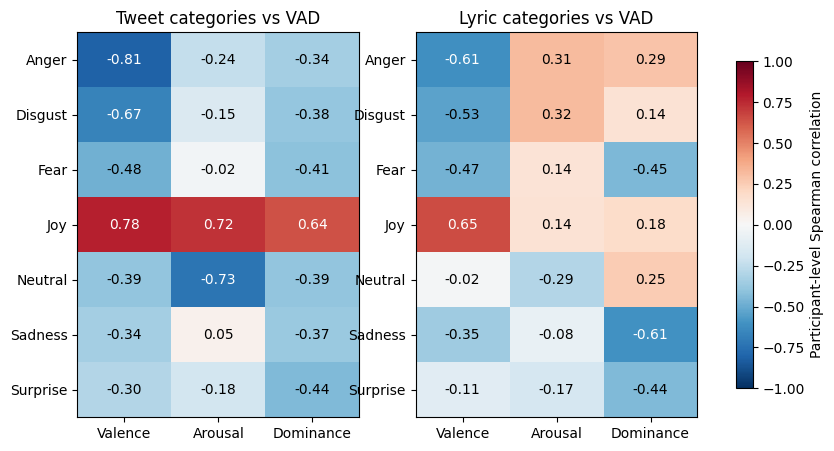

In [ ]:
def correlation_table(data,specifications):
    rows=[]
    for spec in specifications:
        x=data[spec['x']].to_numpy();y=data[spec['y']].to_numpy()
        if np.unique(x).size<2 or np.unique(y).size<2:
            rows.append({**spec,'n':len(data),'rho':np.nan,'p':np.nan,'pearson_r':np.nan});continue
        result=spearmanr(x,y)
        rows.append({**spec,'n':len(data),'rho':float(result.statistic),'p':float(result.pvalue),'pearson_r':float(pearsonr(x,y).statistic)})
    table=pd.DataFrame(rows);table['q']=np.nan
    valid=table.p.notna()
    if valid.any():table.loc[valid,'q']=multipletests(table.loc[valid,'p'],method='fdr_bh')[1]
    return table

emotion_vad=[]

for emotion_source,columns in [('tweet',TCOLS),('lyric',LCOLS)]:
    for VAD_source in ['tweet','lyric']:
        specs=[{'x':col,'y':VAD_source+'_'+dimension,'emotion_source':emotion_source,'VAD_source':VAD_source,'category':category,'dimension':dimension} for category,col in zip(LABELS,columns) for dimension in ['V','A','D']]
        emotion_vad.append(correlation_table(features,specs))

emotion_vad=pd.concat(emotion_vad,ignore_index=True)
emotion_vad.to_csv(RESULTS/'analysis/emotion_vad_correlations.csv',index=False)
restored=emotion_vad.query('emotion_source=="tweet" and VAD_source=="tweet"')

display(restored.pivot(index='category',columns='dimension',values='rho').reindex(index=LABELS,columns=['V','A','D']).round(3))

fig,axes=plt.subplots(1,2,figsize=(10,5))

for ax,source in zip(axes,['tweet','lyric']):
    matrix=emotion_vad.query('emotion_source==@source and VAD_source==@source').pivot(index='category',columns='dimension',values='rho').reindex(index=LABELS,columns=['V','A','D'])
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap='RdBu_r',aspect='auto')
    ax.set_xticks(range(3),['Valence','Arousal','Dominance']);ax.set_yticks(range(7),[s.title() for s in LABELS])
    ax.set_title(source.title()+' categories vs VAD')
    for i in range(7):
        for j in range(3):ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',color='white' if abs(matrix.iloc[i,j])>.55 else 'black')

fig.colorbar(im,ax=axes.tolist(),label='Participant-level Spearman correlation',shrink=.85)
fig.savefig(RESULTS/'figures/category_VAD.png',dpi=180,bbox_inches='tight')
fig.savefig(RESULTS/'figures/category_VAD.pdf',bbox_inches='tight');plt.show()


## 13. Tweet-lyric emotion correspondence and top-category agreement
The full 7-by-7 matrix and matching categories are saved. Matching correlations include all participants and each group, with pointwise participant-bootstrap intervals. No formal difference-between-group correlation test is performed.

Top-category agreement uses the highest **participant-mean** score. It is a descriptive simplification of mixed scores. Cohen's kappa adjusts for chance expected from the two marginal category distributions.


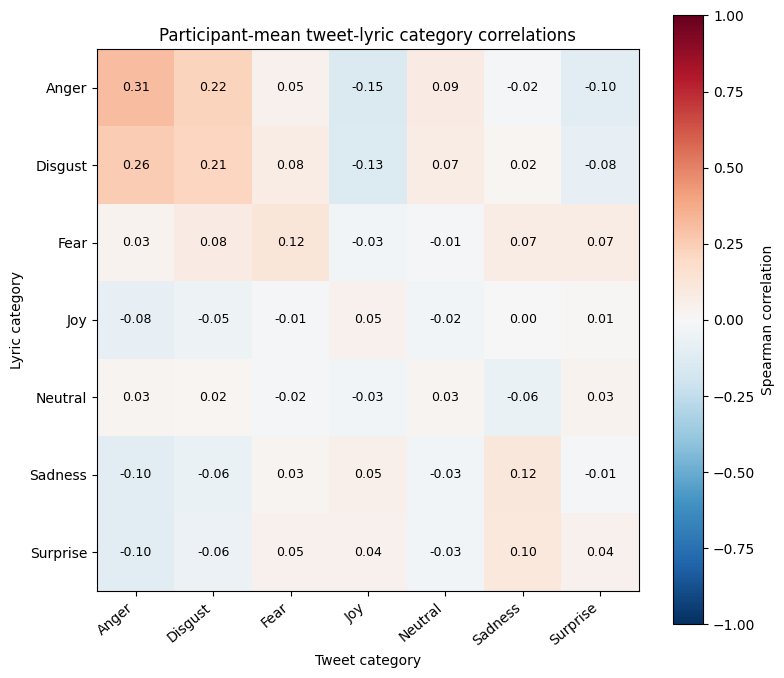

Matching categories: all:   0%|          | 0/7 [00:00<?, ?it/s]

Matching categories: control:   0%|          | 0/7 [00:00<?, ?it/s]

Matching categories: depression:   0%|          | 0/7 [00:00<?, ?it/s]

,category,rho,q,ci_low,ci_high
0,anger,0.307433,5.373017e-93,0.278608,0.335878
1,disgust,0.212383,4.640525e-44,0.183448,0.242512
2,fear,0.117799,2.945042e-14,0.089257,0.146952
3,joy,0.045421,4.253449e-03,0.013960,0.075941
4,neutral,0.028259,6.527381e-02,-0.002964,0.059562
5,sadness,0.115042,9.021612e-14,0.084740,0.145976
6,surprise,0.040679,9.276538e-03,0.012036,0.070357


,group,n,exact_match,chance_expected_match,cohen_kappa
0,all,4256,0.530545,0.509441,0.043021
1,control,3502,0.539692,0.515814,0.049315
2,depression,754,0.488064,0.484092,0.007699


In [ ]:
cross=correlation_table(features,[{'x':tc,'y':lc,'tweet_category':tl,'lyric_category':ll} for tl,tc in zip(LABELS,TCOLS) for ll,lc in zip(LABELS,LCOLS)])
cross.to_csv(RESULTS/'analysis/cross_source_emotion_correlations.csv',index=False)
matrix=cross.pivot(index='lyric_category',columns='tweet_category',values='rho').reindex(index=LABELS,columns=LABELS)
fig,ax=plt.subplots(figsize=(8,7));im=ax.imshow(matrix,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(7),[s.title() for s in LABELS],rotation=40,ha='right');ax.set_yticks(range(7),[s.title() for s in LABELS])
ax.set_xlabel('Tweet category');ax.set_ylabel('Lyric category');ax.set_title('Participant-mean tweet-lyric category correlations')

for i in range(7):
    for j in range(7):ax.text(j,i,f'{matrix.iloc[i,j]:.2f}',ha='center',va='center',fontsize=9,color='white' if abs(matrix.iloc[i,j])>.55 else 'black')

fig.colorbar(im,ax=ax,label='Spearman correlation');fig.tight_layout()
fig.savefig(RESULTS/'figures/tweet_lyric_categories.png',dpi=180);fig.savefig(RESULTS/'figures/tweet_lyric_categories.pdf');plt.show()

rng=np.random.default_rng(20261012);matching=[];agreements=[]

for group in ['all','control','depression']:
    data=features if group=='all' else features[features.disorder.eq(group)]
    table=correlation_table(data,[{'x':tc,'y':lc,'category':label,'group':group} for label,tc,lc in zip(LABELS,TCOLS,LCOLS)])
    for row in tqdm(table.to_dict('records'),desc='Matching categories: '+group):
        x=data[row['x']].to_numpy();y=data[row['y']].to_numpy();values=[]
        for _ in range(BOOTSTRAPS):
            idx=rng.integers(0,len(data),len(data));values.append(spearmanr(x[idx],y[idx]).statistic)
        row['ci_low'],row['ci_high']=map(float,np.nanquantile(values,[.025,.975]));matching.append(row)
    t=data[TCOLS].to_numpy().argmax(axis=1);l=data[LCOLS].to_numpy().argmax(axis=1)
    chance=float(np.bincount(t,minlength=7)@np.bincount(l,minlength=7)/len(data)**2)
    agreements.append({'group':group,'n':len(data),'exact_match':float((t==l).mean()),'chance_expected_match':chance,'cohen_kappa':float(cohen_kappa_score(t,l,labels=range(7)))})
    counts_table=pd.crosstab(pd.Series(l,name='lyric'),pd.Series(t,name='tweet')).reindex(index=range(7),columns=range(7),fill_value=0)
    counts_table.index=LABELS;counts_table.columns=LABELS;counts_table.to_csv(RESULTS/f'analysis/top_category_counts_{group}.csv')

matching=pd.DataFrame(matching);matching.to_csv(RESULTS/'analysis/matching_emotion_correlations.csv',index=False)
agreements=pd.DataFrame(agreements);agreements.to_csv(RESULTS/'analysis/top_category_agreement.csv',index=False)
display(matching.query('group=="all"')[['category','rho','q','ci_low','ci_high']]);display(agreements)

within=[]

for source,cols in [('tweet',TCOLS),('lyric',LCOLS)]:
    for i in range(7):
        for j in range(i+1,7):within.append({'x':cols[i],'y':cols[j],'source':source,'category_1':LABELS[i],'category_2':LABELS[j]})

correlation_table(features,within).to_csv(RESULTS/'analysis/within_source_category_correlations.csv',index=False)


## 14. Compare category scores between depression and control groups
Fourteen participant-level Mann-Whitney tests form one BH family: seven scores from tweets and seven from lyrics. Cliff's delta is oriented as depression minus control. Negative values indicate lower scores in depression.

The intervals resample participants within groups and are pointwise. Shared songs and dependence between participants are not fully modelled. The disclosure-derived dataset labels are not clinical ground truth.


tweet category group tests:   0%|          | 0/7 [00:00<?, ?it/s]

lyric category group tests:   0%|          | 0/7 [00:00<?, ?it/s]

,source,category,delta,q,ci_low,ci_high
0,tweet,anger,0.080341,1.057875e-03,0.035181,0.126489
1,tweet,disgust,0.233357,3.630102e-23,0.190733,0.275892
2,tweet,fear,0.349695,2.851880e-50,0.310753,0.389973
3,tweet,joy,0.042843,8.219816e-02,-0.001405,0.087226
4,tweet,neutral,-0.211100,2.984163e-19,-0.253826,-0.169525
5,tweet,sadness,0.347892,4.618050e-50,0.309072,0.386797
6,tweet,surprise,0.194606,1.307375e-16,0.151302,0.235597
7,lyric,anger,-0.074962,2.138889e-03,-0.118099,-0.028601
8,lyric,disgust,0.000089,9.969629e-01,-0.042744,0.045193
9,lyric,fear,0.113308,2.379256e-06,0.066750,0.159387


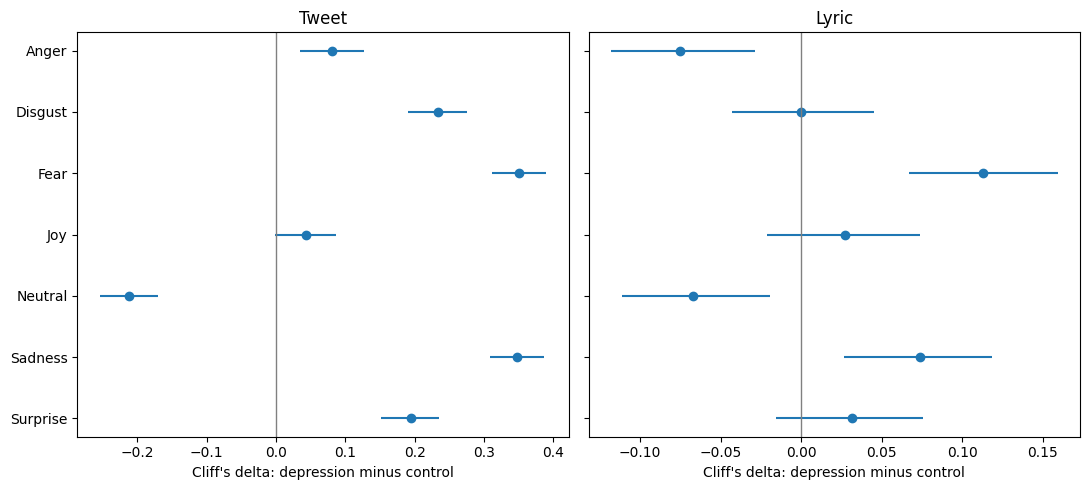

In [ ]:
rng=np.random.default_rng(20261013);group_rows=[]

for source,cols in [('tweet',TCOLS),('lyric',LCOLS)]:
    for label,col in tqdm(list(zip(LABELS,cols)),desc=source+' category group tests'):
        x=features.loc[features.disorder.eq('depression'),col].to_numpy()
        y=features.loc[features.disorder.eq('control'),col].to_numpy()
        result=mannwhitneyu(x,y,alternative='two-sided',method='asymptotic')
        delta=float(2*result.statistic/(len(x)*len(y))-1)
        values=[]
        for _ in range(BOOTSTRAPS):
            a=rng.choice(x,len(x),True);b=rng.choice(y,len(y),True)
            values.append(2*mannwhitneyu(a,b,alternative='two-sided',method='asymptotic').statistic/(len(a)*len(b))-1)
        lo,hi=np.quantile(values,[.025,.975])
        group_rows.append({'source':source,'category':label,'depression_n':len(x),'control_n':len(y),
          'depression_mean':float(x.mean()),'control_mean':float(y.mean()),'depression_median':float(np.median(x)),
          'control_median':float(np.median(y)),'delta':delta,'p':float(result.pvalue),'ci_low':float(lo),'ci_high':float(hi)})

group_tests=pd.DataFrame(group_rows);group_tests['q']=multipletests(group_tests.p,method='fdr_bh')[1]
group_tests.to_csv(RESULTS/'analysis/emotion_group_tests.csv',index=False)
display(group_tests[['source','category','delta','q','ci_low','ci_high']])

fig,axes=plt.subplots(1,2,figsize=(11,5),sharey=True)

for ax,source in zip(axes,['tweet','lyric']):
    sub=group_tests.query('source==@source').set_index('category').reindex(LABELS)
    ax.hlines(np.arange(7),sub.ci_low,sub.ci_high,color='tab:blue',lw=1.5)
    ax.plot(sub.delta,np.arange(7),'o',color='tab:blue')
    ax.axvline(0,color='grey',lw=1);ax.set_title(source.title());ax.set_xlabel("Cliff's delta: depression minus control")

axes[0].set_yticks(range(7),[s.title() for s in LABELS]);axes[0].invert_yaxis();fig.tight_layout()
fig.savefig(RESULTS/'figures/category_group_effects.png',dpi=180);fig.savefig(RESULTS/'figures/category_group_effects.pdf');plt.show()


## 15. Compare predictive features using the exact same participant folds
The existing VAD comparator uses six features. The extension tests categorical tweets (7), categorical lyrics (7), both (14), and VAD plus categories (20). The baseline VAD predictions are reused, with their original settings.

Train-fold scaling and imputation are fitted inside each fold. Logistic regression settings: `C=1`, balanced class weights. Forest settings: 300 trees, minimum leaf 3, balanced subsampling. No target-based tuning occurs.

The scores measure internal depression/control label discrimination. Feature counts and source training differ, so this does not isolate a causal advantage of categorical versus dimensional emotion.


In [ ]:
VADCOLS=[source+'_'+d for source in ['tweet','lyric'] for d in ['V','A','D']]
feature_sets={'category_tweets':TCOLS,'category_lyrics':LCOLS,'category_both':TCOLS+LCOLS,'VAD_and_categories':VADCOLS+TCOLS+LCOLS}
classifiers={'LR':make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),LogisticRegression(C=1,class_weight='balanced',max_iter=5000,random_state=SEED))}

if INCLUDE_RANDOM_FOREST:
    classifiers['RF']=make_pipeline(SimpleImputer(strategy='median'),RandomForestClassifier(n_estimators=300,min_samples_leaf=3,class_weight='balanced_subsample',random_state=SEED,n_jobs=2))

y=features.disorder.eq('depression').astype(int).to_numpy();fold_id=fold_assignments.fold.to_numpy()
assert set(fold_id)==set(range(1,6))

old_oof=pd.read_csv(INPUT/'analysis/classification_oof.csv',dtype={'participant_id':str})
old_oof=old_oof[old_oof.model.isin(classifiers)].copy();old_oof['features']='VAD_both';old_oof['feature_count']=6
old_folds=pd.read_csv(INPUT/'analysis/classification_folds.csv')
old_folds=old_folds[old_folds.model.isin(classifiers)].copy();old_folds['features']='VAD_both';old_folds['feature_count']=6

for model in classifiers:
    baseline_rows=old_oof[old_oof.model.eq(model)].set_index('participant_id').loc[features.participant_id]
    assert np.array_equal(baseline_rows.y,y) and np.array_equal(baseline_rows.fold,fold_id)

oof_parts=[old_oof];fold_rows=[]

for name,cols in feature_sets.items():
    X=features[cols].to_numpy();assert np.isfinite(X).all()
    for model_name,prototype in classifiers.items():
        probability=np.empty(len(features));predicted=np.empty(len(features),dtype=int)
        for fold in tqdm(range(1,6),desc=name+' '+model_name):
            validation=fold_id==fold;training=~validation
            fitted=clone(prototype).fit(X[training],y[training])
            probability[validation]=fitted.predict_proba(X[validation])[:,1]
            predicted[validation]=fitted.predict(X[validation])
            fold_rows.append({'features':name,'feature_count':len(cols),'model':model_name,'fold':fold,
                'auroc':float(roc_auc_score(y[validation],probability[validation])),
                'balanced_accuracy':float(balanced_accuracy_score(y[validation],predicted[validation]))})
        oof_parts.append(pd.DataFrame({'participant_id':features.participant_id,'features':name,'feature_count':len(cols),
                 'model':model_name,'fold':fold_id,'y':y,'probability':probability,'predicted':predicted}))
        pd.concat(oof_parts,ignore_index=True).to_csv(RESULTS/'analysis/classification_oof.csv',index=False)

fold_results=pd.concat([old_folds,pd.DataFrame(fold_rows)],ignore_index=True)
oof=pd.concat(oof_parts,ignore_index=True)
fold_results.to_csv(RESULTS/'analysis/classification_folds.csv',index=False)

print('All feature comparisons fitted on the same saved folds.')


category_tweets LR:   0%|          | 0/5 [00:00<?, ?it/s]

category_tweets RF:   0%|          | 0/5 [00:00<?, ?it/s]

category_lyrics LR:   0%|          | 0/5 [00:00<?, ?it/s]

category_lyrics RF:   0%|          | 0/5 [00:00<?, ?it/s]

category_both LR:   0%|          | 0/5 [00:00<?, ?it/s]

category_both RF:   0%|          | 0/5 [00:00<?, ?it/s]

VAD_and_categories LR:   0%|          | 0/5 [00:00<?, ?it/s]

VAD_and_categories RF:   0%|          | 0/5 [00:00<?, ?it/s]

All feature comparisons fitted on the same saved folds.


## 16. Summarise classification and paired AUROC differences
Fold standard deviation describes variation across the five folds. The bootstrap intervals condition on the saved out-of-fold predictions and do not include full retraining uncertainty.

Paired intervals are exploratory and not multiplicity-adjusted. An interval containing zero does not establish a clear improvement. No new categorical permutation test or external clinical evaluation is performed.


,features,feature_count,model,n,mean_auroc,sd_auroc,mean_balanced_accuracy,sd_balanced_accuracy,pooled_auroc,ci_low,ci_high
0,VAD_and_categories,20,LR,4256,0.721741,0.019887,0.662285,0.015144,0.720750,0.701358,0.739522
1,VAD_and_categories,20,RF,4256,0.732135,0.023345,0.556374,0.018583,0.731094,0.711783,0.749878
2,VAD_both,6,LR,4256,0.641034,0.020906,0.600621,0.017996,0.641020,0.618705,0.662573
3,VAD_both,6,RF,4256,0.637752,0.014316,0.515276,0.005251,0.637536,0.617264,0.658559
4,category_both,14,LR,4256,0.720639,0.015622,0.658223,0.015018,0.719822,0.700633,0.738238
5,category_both,14,RF,4256,0.726429,0.019027,0.554843,0.016149,0.724909,0.705410,0.744310
6,category_lyrics,7,LR,4256,0.590169,0.016481,0.571537,0.015925,0.589653,0.566583,0.611044
7,category_lyrics,7,RF,4256,0.544725,0.019234,0.505039,0.009854,0.544323,0.521684,0.566479
8,category_tweets,7,LR,4256,0.715766,0.015253,0.650527,0.020745,0.714825,0.695867,0.733677
9,category_tweets,7,RF,4256,0.706845,0.008943,0.557353,0.007562,0.706890,0.688422,0.727216


,model,comparison,pooled_auroc_difference,ci_low,ci_high
0,LR,category_both_minus_VAD_both,0.078802,0.061231,0.096471
1,LR,VAD_and_categories_minus_VAD_both,0.079730,0.060454,0.098078
2,LR,VAD_and_categories_minus_category_both,0.000928,-0.005403,0.007182
3,LR,category_both_minus_category_tweets,0.004997,-0.000443,0.010579
4,RF,category_both_minus_VAD_both,0.087373,0.065997,0.108922
5,RF,VAD_and_categories_minus_VAD_both,0.093559,0.073648,0.113277
6,RF,VAD_and_categories_minus_category_both,0.006185,-0.000190,0.012819
7,RF,category_both_minus_category_tweets,0.018019,0.006760,0.029151


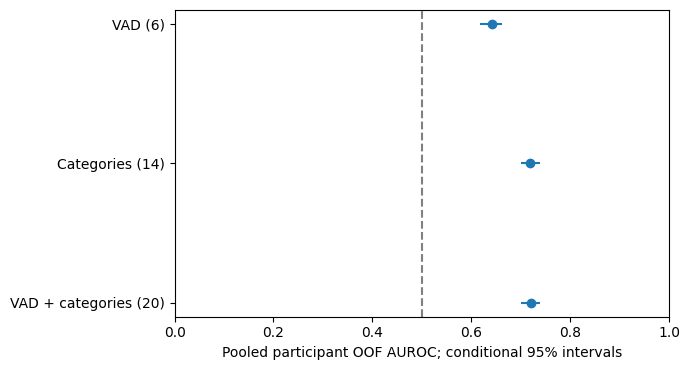

In [20]:
rng=np.random.default_rng(20261014);summary_rows=[]
for (name,model),data in oof.groupby(['features','model']):
    data=data.sort_values('participant_id');yy=data.y.to_numpy();p=data.probability.to_numpy()
    positive=np.flatnonzero(yy==1);negative=np.flatnonzero(yy==0);values=[]
    for _ in range(BOOTSTRAPS):
        idx=np.r_[rng.choice(positive,len(positive),True),rng.choice(negative,len(negative),True)]
        values.append(roc_auc_score(yy[idx],p[idx]))
    ff=fold_results[(fold_results.features==name)&(fold_results.model==model)]
    summary_rows.append({'features':name,'feature_count':int(data.feature_count.iloc[0]),'model':model,'n':len(data),
        'mean_auroc':float(ff.auroc.mean()),'sd_auroc':float(ff.auroc.std(ddof=1)),
        'mean_balanced_accuracy':float(ff.balanced_accuracy.mean()),'sd_balanced_accuracy':float(ff.balanced_accuracy.std(ddof=1)),
        'pooled_auroc':float(roc_auc_score(yy,p)),'ci_low':float(np.quantile(values,.025)),'ci_high':float(np.quantile(values,.975))})
classification_summary=pd.DataFrame(summary_rows)
classification_summary.to_csv(RESULTS/'analysis/classification_summary.csv',index=False)

paired_rows=[];rng=np.random.default_rng(20261015)
for model in classifiers:
    entries={name:oof[(oof.features==name)&(oof.model==model)].sort_values('participant_id') for name in ['VAD_both']+list(feature_sets)}
    for a,b in [('category_both','VAD_both'),('VAD_and_categories','VAD_both'),('VAD_and_categories','category_both'),('category_both','category_tweets')]:
        aa=entries[a];bb=entries[b]
        assert aa.participant_id.tolist()==bb.participant_id.tolist() and np.array_equal(aa.fold,bb.fold)
        yy=aa.y.to_numpy();p=aa.probability.to_numpy();q=bb.probability.to_numpy()
        positive=np.flatnonzero(yy==1);negative=np.flatnonzero(yy==0);values=[]
        for _ in range(BOOTSTRAPS):
            idx=np.r_[rng.choice(positive,len(positive),True),rng.choice(negative,len(negative),True)]
            values.append(roc_auc_score(yy[idx],p[idx])-roc_auc_score(yy[idx],q[idx]))
        paired_rows.append({'model':model,'comparison':a+'_minus_'+b,'pooled_auroc_difference':float(roc_auc_score(yy,p)-roc_auc_score(yy,q)),
                            'ci_low':float(np.quantile(values,.025)),'ci_high':float(np.quantile(values,.975))})
paired_comparisons=pd.DataFrame(paired_rows)
paired_comparisons.to_csv(RESULTS/'analysis/paired_comparisons.csv',index=False)
display(classification_summary);display(paired_comparisons)

plot=classification_summary.query('model=="LR"').set_index('features').loc[['VAD_both','category_both','VAD_and_categories']]
fig,ax=plt.subplots(figsize=(7,3.8))
ax.hlines(np.arange(3),plot.ci_low,plot.ci_high,color='tab:blue',lw=1.5)
ax.plot(plot.pooled_auroc,np.arange(3),'o',color='tab:blue')
ax.set_yticks(range(3),['VAD (6)','Categories (14)','VAD + categories (20)']);ax.invert_yaxis()
ax.axvline(.5,color='grey',ls='--');ax.set_xlim(0,1);ax.set_xlabel('Pooled participant OOF AUROC; conditional 95% intervals');fig.tight_layout()
fig.savefig(RESULTS/'figures/representation_classification.png',dpi=180);fig.savefig(RESULTS/'figures/representation_classification.pdf');plt.show()


## 17. Preserve the original table and export the results


In [ ]:
historical={'joy':[.542,.108,.141],'neutral':[.083,-.440,-.138],'anger':[-.282,.056,.096],
            'sadness':[-.241,-.059,-.213],'fear':[-.231,-.089,-.094],'disgust':[-.222,-.050,-.106],'surprise':[.140,-.078,-.100]}

history=[]

for label in LABELS:
    for j,dimension in enumerate(['V','A','D']):
        row=restored[(restored.category==label)&(restored.dimension==dimension)].iloc[0]
        history.append({'category':label,'dimension':dimension,'original_biography_row_weighted_rho':historical[label][j],
                        'new_timeline_participant_mean_rho':float(row.rho),'new_q':float(row.q),
                        'comparison_scope':'Source, models, sample and weighting changed; not a controlled before/after comparison'})
historical_comparison=pd.DataFrame(history)
historical_comparison.to_csv(RESULTS/'analysis/original_vs_corrected_category_VAD.csv',index=False)
display(historical_comparison)
report_lines=[
 '# Seven-category comparison results',
 '',
 'The original seven-category vocabulary is preserved. The Hartmann checkpoint is not reproduced: a GoEmotions-trained MiniLM embedding classifier is used because raw target tweets are unavailable.',
 '',
 f'Paired sample: {len(features):,} participants, {int(features.tweet_count.sum()):,} tweets and {len(songs):,} participant-song records.',
 f'Source model: selected C={selected_C}; official mapped GoEmotions test n={int(test_mask.sum()):,}.',
 f'Source test cross-entropy: {source_metrics.iloc[0].cross_entropy:.4f}; baseline: {source_metrics.iloc[1].cross_entropy:.4f}.',
 '',
 '## Classification (fold mean AUROC +/- fold standard deviation)',
]

for row in classification_summary.itertuples():
    report_lines.append(f'- {row.model} {row.features} ({row.feature_count} features): {row.mean_auroc:.3f} +/- {row.sd_auroc:.3f}; balanced accuracy {row.mean_balanced_accuracy:.3f}.')

report_lines.extend(['','## Interpretation','',
 'All new target results are exploratory. Separate BH families do not give an overall thesis-wide FDR. The paired OOF intervals are unadjusted and conditional on fixed predictions.',
 'GoEmotions source errors do not validate tweet or lyric accuracy. Correlations between category scores and VAD are agreement between predictions, not independent human-rated validation.',
 'Feature counts and scoring objectives differ. Internal depression/control label discrimination is not clinical diagnostic validity. Categorical results have not undergone the complete VAD sensitivity battery.',
 'Original biography coefficients are historical and cannot be directly interpreted as a controlled baseline for the timeline analysis.',
 '', '## Reproduction', '',
 'Keep this notebook and the input bundle. The input and model manifests record hashes, splits, package versions, mappings, settings and the frozen encoder revision. Drive checkpoints resume source encoding and completed tweet files.',
])

(RESULTS/'RESULTS_SUMMARY.md').write_text('\n'.join(report_lines)+'\n')

write_json(RESULTS/'run_manifest.json',{'code_version':CODE_VERSION,'input_zip_sha256':sha256(INPUT_ZIP),
 'model_sha256':model_hash,'encoder_revision':ENCODER_REVISION,'GoEmotions_revision':GO_REVISION,
 'categories':LABELS,'participants':len(features),'tweets':int(features.tweet_count.sum()),'songs':len(songs),
 'BOOTSTRAPS':BOOTSTRAPS,'INCLUDE_RANDOM_FOREST':INCLUDE_RANDOM_FOREST,
 'python':platform.python_version(),'packages':source_manifest['packages'],'finished_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime())})

output_files={str(p.relative_to(RESULTS)):sha256(p) for p in sorted(RESULTS.rglob('*')) if p.is_file() and p.name!='OUTPUT_HASHES.json'}

write_json(RESULTS/'OUTPUT_HASHES.json',output_files)

archive=Path(shutil.make_archive('/content/GoEmotions-comparison-results','zip',root_dir=RESULTS))
drive_archive=PROJECT/archive.name;shutil.copy2(archive,drive_archive)
print('Saved result archive to:',drive_archive)

display(Markdown((RESULTS/'RESULTS_SUMMARY.md').read_text()))


,category,dimension,original_biography_row_weighted_rho,new_timeline_participant_mean_rho,new_q,comparison_scope
0,anger,V,-0.282,-0.806698,0.000000e+00,"Source, models, sample and weighting changed; ..."
1,anger,A,0.056,-0.238956,3.075654e-56,"Source, models, sample and weighting changed; ..."
2,anger,D,0.096,-0.336025,1.073096e-112,"Source, models, sample and weighting changed; ..."
3,disgust,V,-0.222,-0.665496,0.000000e+00,"Source, models, sample and weighting changed; ..."
4,disgust,A,-0.050,-0.146172,1.024992e-21,"Source, models, sample and weighting changed; ..."
5,disgust,D,-0.106,-0.383408,7.469960e-149,"Source, models, sample and weighting changed; ..."
6,fear,V,-0.231,-0.478186,1.134335e-241,"Source, models, sample and weighting changed; ..."
7,fear,A,-0.089,-0.024044,1.167966e-01,"Source, models, sample and weighting changed; ..."
8,fear,D,-0.094,-0.410305,3.595064e-172,"Source, models, sample and weighting changed; ..."
9,joy,V,0.542,0.778688,0.000000e+00,"Source, models, sample and weighting changed; ..."


Saved result archive to: /content/drive/MyDrive/Thesis_GoEmotions_Comparison/GoEmotions-comparison-results.zip


# Seven-category comparison results

The original seven-category vocabulary is preserved. The Hartmann checkpoint is not reproduced: a GoEmotions-trained MiniLM embedding classifier is used because raw target tweets are unavailable.

Paired sample: 4,256 participants, 6,345,978 tweets and 47,204 participant-song records.
Source model: selected C=1.0; official mapped GoEmotions test n=5,427.
Source test cross-entropy: 1.0696; baseline: 1.5360.

## Classification (fold mean AUROC +/- fold standard deviation)
- LR VAD_and_categories (20 features): 0.722 +/- 0.020; balanced accuracy 0.662.
- RF VAD_and_categories (20 features): 0.732 +/- 0.023; balanced accuracy 0.556.
- LR VAD_both (6 features): 0.641 +/- 0.021; balanced accuracy 0.601.
- RF VAD_both (6 features): 0.638 +/- 0.014; balanced accuracy 0.515.
- LR category_both (14 features): 0.721 +/- 0.016; balanced accuracy 0.658.
- RF category_both (14 features): 0.726 +/- 0.019; balanced accuracy 0.555.
- LR category_lyrics (7 features): 0.590 +/- 0.016; balanced accuracy 0.572.
- RF category_lyrics (7 features): 0.545 +/- 0.019; balanced accuracy 0.505.
- LR category_tweets (7 features): 0.716 +/- 0.015; balanced accuracy 0.651.
- RF category_tweets (7 features): 0.707 +/- 0.009; balanced accuracy 0.557.

## Interpretation

All new target results are exploratory. Separate BH families do not give an overall thesis-wide FDR. The paired OOF intervals are unadjusted and conditional on fixed predictions.
GoEmotions source errors do not validate tweet or lyric accuracy. Correlations between category scores and VAD are agreement between predictions, not independent human-rated validation.
Feature counts and scoring objectives differ. Internal depression/control label discrimination is not clinical diagnostic validity. Categorical results have not undergone the complete VAD sensitivity battery.
Original biography coefficients are historical and cannot be directly interpreted as a controlled baseline for the timeline analysis.

## Reproduction

Keep this notebook and the input bundle. The input and model manifests record hashes, splits, package versions, mappings, settings and the frozen encoder revision. Drive checkpoints resume source encoding and completed tweet files.


In [22]:
from google.colab import files
files.download(str(archive))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>